### **Arabic Handwritten Chars Classification Course Project**



### **Table of Content**



1.   Import Libraries
2.   Load the Dataset and Extract Labels
3.   Data Pre-Processing
4.   Build, Train and Evaluate Deep Neural Network Architecture
    1. Define Plot Function
    2. Define Deep Neural Networks
        *   First Deep Neural Network
        *   Second Deep Neural Network
        *   Third Deep Neural Network
        *   Fourth Deep Neural Network
        *   Fifth Deep Neural Network
        *   Sixth Deep Neural Network - Best Architecture
    











### 1.   Import Libraries

In [1]:
import numpy as np
import pandas as pd
import cv2
import os
import re
import matplotlib.pylab as plt
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1,l2,l1_l2
import tensorflow as tf

###2.   Load the Dataset and Extract Labels


In [2]:
!cp kaggle.json ~./kaggle
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/rashwan/arabic-chars-mnist")

'cp' is not recognized as an internal or external command,
operable program or batch file.


Skipping, found downloaded files in ".\arabic-chars-mnist" (use force=True to force download)


In [3]:
# Set the test and train paths
test_path = r'F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\arabic-chars-mnist\test'
train_path = r'F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\arabic-chars-mnist\train'

In [4]:
def dataset_labels(path):
  # Initialize empty list
  data = []
  # Loop into directory
  for filename in os.listdir(path):
    # Extract label
    img_label = re.sub('[0-9]+|\.jpg$', '', filename)
    # refine the image path
    img_path = os.path.join(path, filename)
    img = cv2.imread(img_path)
    # Add image path and image label to list
    data.append((img, img_label))
  # return the list
  return data

In [5]:
train_dataset = dataset_labels(train_path)
test_dataset = dataset_labels(test_path)

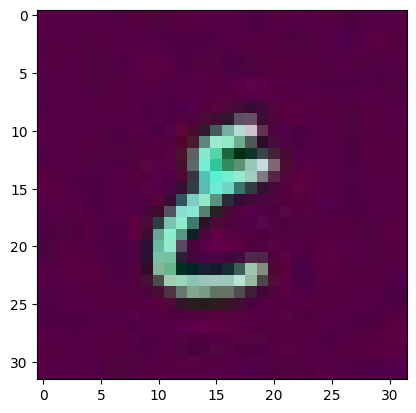

Image Label:  ain


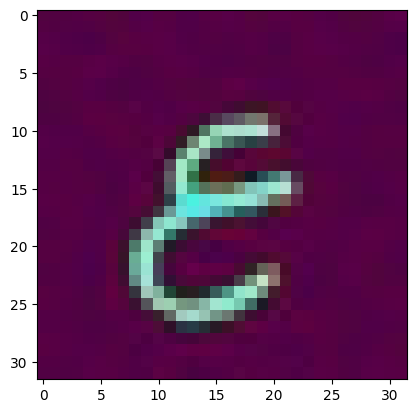

Image Label:  ain


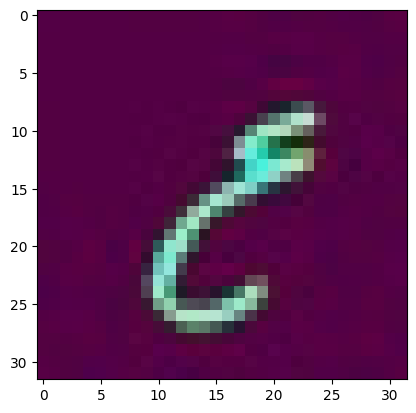

Image Label:  ain


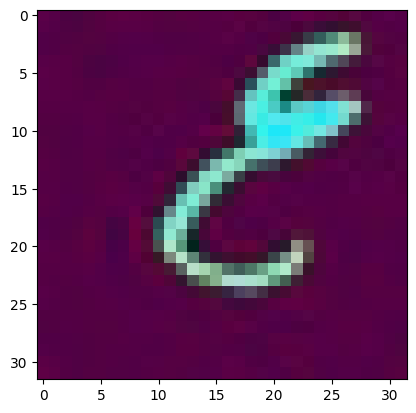

Image Label:  ain


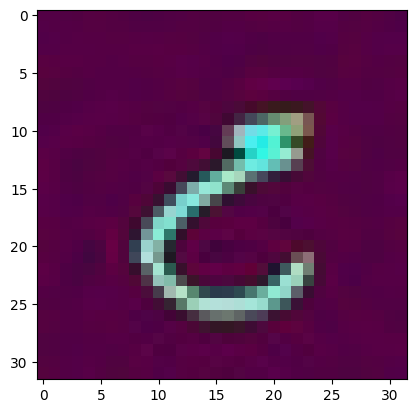

Image Label:  ain


In [6]:
i = 0
for img, label in train_dataset:
    i += 1
    plt.imshow(img)
    plt.show()
    print("Image Label: ", label)
    if (i == 5):
        break

### 3.   Data Pre-Processing


In [7]:
train_label = [0] * len(train_dataset)
train_img = [0] * len(train_dataset)
count = 0

for data_images,  data_label in train_dataset:
   train_label[count] = data_label
   train_img[count] = data_images
   count +=1

test_label = [0] * len(test_dataset)
test_img = [0] * len(test_dataset)
count = 0

for data_images,  data_label in test_dataset:
   test_label[count] = data_label
   test_img[count] = data_images
   count +=1

In [8]:
lb=LabelEncoder()

train_label = lb.fit_transform(train_label)
test_label = lb.fit_transform(test_label)

In [9]:
train_shuffled, train_labels_shuffled = shuffle(train_img , train_label, random_state=42)
test_shuffled, test_labels_shuffled = shuffle(test_img, test_label, random_state=42)

In [10]:
# Convert list to set to get unique elements
list(set(train_labels_shuffled))

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27)]

In [11]:
train = np.array(train_shuffled)
train_labels = np.array(train_labels_shuffled)

test = np.array(test_shuffled)
test_labels = np.array(test_labels_shuffled)

In [12]:
print("Train Data shape", train.shape)
print("Train Labels shape", train_labels.shape)
print("Test Data shape", test.shape)
print("Test Labels shape", test_labels.shape)

Train Data shape (13440, 32, 32, 3)
Train Labels shape (13440,)
Test Data shape (3360, 32, 32, 3)
Test Labels shape (3360,)


In [13]:
# Normalize pixel values to 0,1
train, test = train / 255.0, test / 255.0

### 4.   Build, Train and Evaluate Deep Neural Network Architecture

#### 1. Define Plot Function

In [14]:
def plot_history(history):

  fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(10, 5))


  axes[0].plot(history['accuracy'], label='Train Accuracy')
  axes[0].plot(history['val_accuracy'], label='Validation Accuracy')
  axes[0].set_title('Training and Validation Accuracy')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Accuracy')
  axes[0].legend(loc='lower right')


  axes[1].plot(history['loss'], label='Train Loss')
  axes[1].plot(history['val_loss'], label='Validation Loss')
  axes[1].set_title('Training and Validation Loss')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Loss')
  axes[1].legend(loc='upper right')

  plt.tight_layout()
  plt.show()

#### 2. Define Deep Neural Networks


        *   First Deep Neural Network


In [15]:
model_1=Sequential()

model_1=Sequential([
    Conv2D(16,(3,3),strides=1,activation='relu', input_shape=(32, 32, 3)),
    Conv2D(32,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),


    Conv2D(64,(3,3),strides=1,activation='relu'),
    Conv2D(128,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(28,activation='softmax'),
  ])

model_1.summary()

c:\Users\hagar\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510,780 (1.95 MB)

 Trainable params: 510,780 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model_1.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [17]:
his_1 = model_1.fit(train, train_labels, epochs=10, validation_split=0.2, batch_size=128)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.3498 - loss: 2.1863 - val_accuracy: 0.5513 - val_loss: 1.3544
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.7005 - loss: 0.9155 - val_accuracy: 0.7556 - val_loss: 0.7923
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8237 - loss: 0.5506 - val_accuracy: 0.8478 - val_loss: 0.4765
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8775 - loss: 0.3796 - val_accuracy: 0.8731 - val_loss: 0.3909
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9124 - loss: 0.2714 - val_accuracy: 0.8791 - val_loss: 0.3761
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9298 - loss: 0.2161 - val_accuracy: 0.8996 - val_loss: 0.3346
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9505 - loss: 0.1579 - val_accuracy: 0.8921 - val_loss: 0.3519
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9540 - loss: 0.1365 - val_accuracy: 0.8921 - v

In [18]:
loss, acc = model_1.evaluate(test, test_labels)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9000 - loss: 0.3831


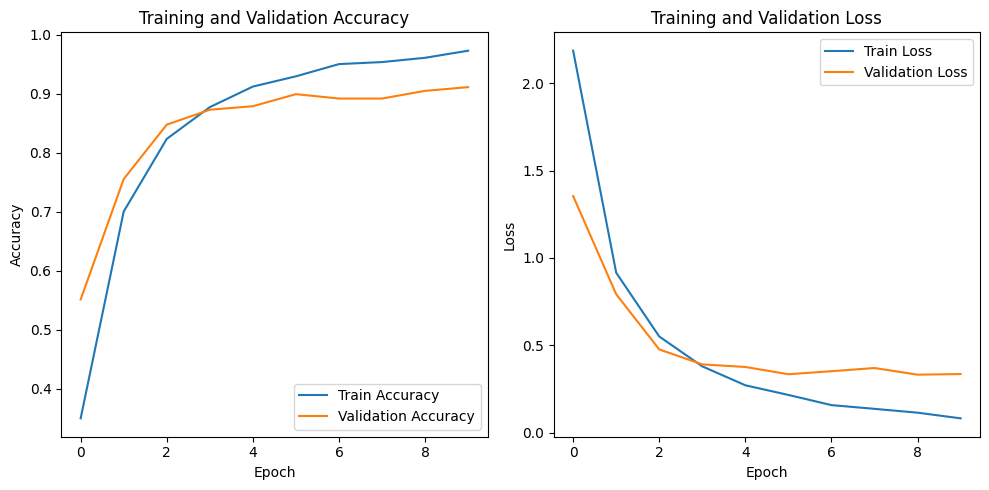

In [19]:
plot_history(his_1.history)

        *   Second Deep Neural Network

In [20]:
model_2=Sequential()

model_2=Sequential([
    Conv2D(16,(3,3),strides=1,activation='relu', input_shape=(32, 32, 3)),
    Conv2D(32,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),


    Conv2D(64,(3,3),strides=1,activation='relu'),
    Conv2D(128,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(28,activation='softmax'),
  ])
model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510,780 (1.95 MB)

 Trainable params: 510,780 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_2.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [22]:
his_2 = model_2.fit(train, train_labels, epochs=10, validation_split=0.2, batch_size=128)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.1800 - loss: 2.7698 - val_accuracy: 0.4736 - val_loss: 1.7775
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.4270 - loss: 1.7663 - val_accuracy: 0.6786 - val_loss: 1.0720
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.5849 - loss: 1.2482 - val_accuracy: 0.7597 - val_loss: 0.7344
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.6707 - loss: 0.9826 - val_accuracy: 0.8051 - val_loss: 0.5868
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.7079 - loss: 0.8581 - val_accuracy: 0.8516 - val_loss: 0.4820
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.7473 - loss: 0.7351 - val_accuracy: 0.8664 - val_loss: 0.4066
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.7749 - loss: 0.6498 - val_accuracy: 0.8642 - val_loss: 0.4154
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.7994 - loss: 0.5906 - val_accuracy: 0.8869 - v

In [23]:
loss, acc = model_2.evaluate(test, test_labels)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8991 - loss: 0.3353


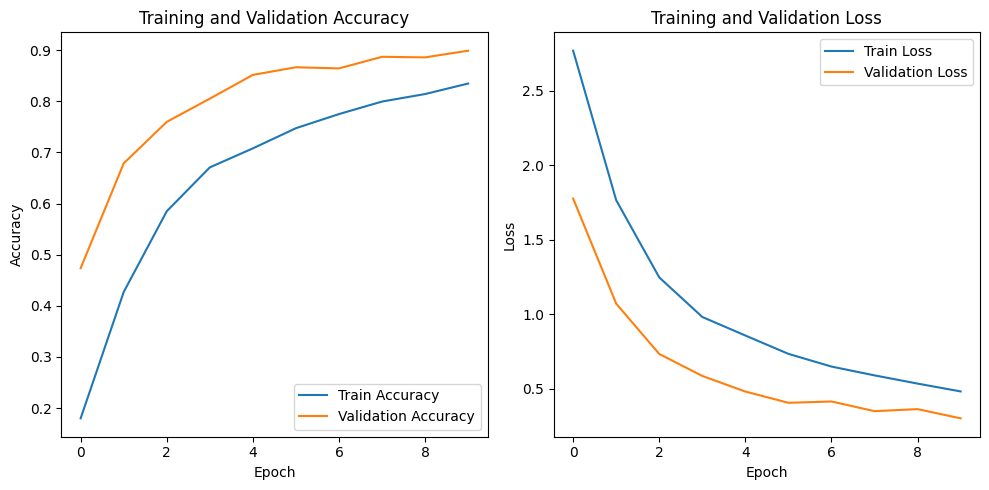

In [24]:
plot_history(his_2.history)

        *   Third Deep Neural Network

In [25]:
model_3=Sequential()

model_3=Sequential([
    Conv2D(16,(3,3),strides=1,activation='relu', input_shape=(32, 32, 3)),
    Conv2D(32,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(64,(3,3),strides=1,activation='relu'),
    Conv2D(128,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(28,activation='softmax'),
  ])
model_3.summary()

model_3.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,420 (1.95 MB)

 Trainable params: 511,100 (1.95 MB)

 Non-trainable params: 320 (1.25 KB)

In [26]:
his_3 = model_3.fit(train, train_labels, epochs=15, validation_split=0.2, batch_size=64)

Epoch 1/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3780 - loss: 2.1358 - val_accuracy: 0.0324 - val_loss: 5.2678
Epoch 2/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7155 - loss: 0.8747 - val_accuracy: 0.0945 - val_loss: 5.2233
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8334 - loss: 0.5186 - val_accuracy: 0.7054 - val_loss: 0.9589
Epoch 4/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8810 - loss: 0.3634 - val_accuracy: 0.8508 - val_loss: 0.4169
Epoch 5/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9116 - loss: 0.2626 - val_accuracy: 0.8638 - val_loss: 0.4645
Epoch 6/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9290 - loss: 0.2092 - val_accuracy: 0.8531 - val_loss: 0.4696
Epoch 7/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9393 - loss: 0.1817 - val_accuracy: 0.8571 - val_loss: 0.4960
Epoch 8/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9495 - loss: 0.1475 - val_accu

In [27]:
loss, acc = model_3.evaluate(test, test_labels)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9354 - loss: 0.2548


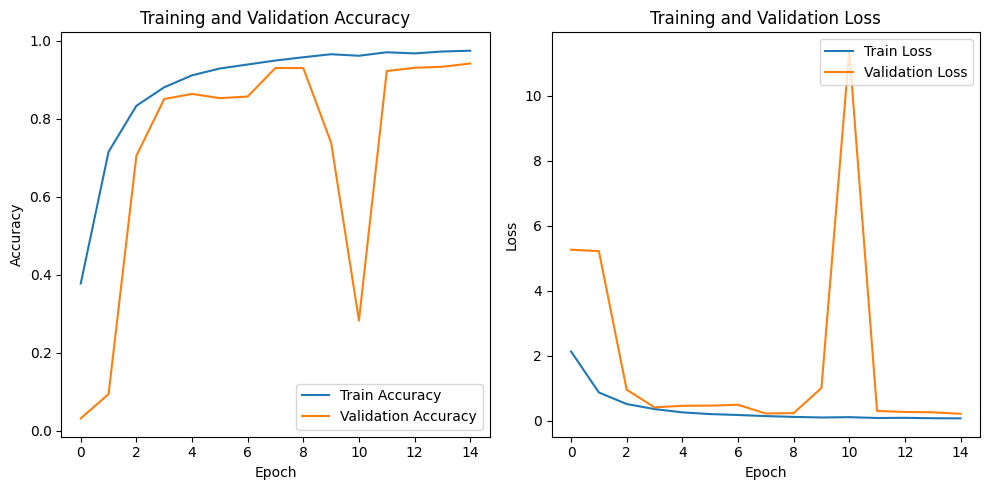

In [28]:
plot_history(his_3.history)

        *   Fourth Deep Neural Network

In [29]:
model_4=Sequential()

model_4=Sequential([
    Conv2D(16,(3,3),strides=1,activation='relu', input_shape=(32, 32, 3)),
    Conv2D(32,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(64,(3,3),strides=1,activation='relu'),
    Conv2D(128,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Flatten(),

    Dense(128,activation='relu',kernel_regularizer=l1_l2(l1=0.001, l2=0.001)),
    Dropout(0.5),
    Dense(28,activation='softmax'),
  ])
model_4.summary()

model_4.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,420 (1.95 MB)

 Trainable params: 511,100 (1.95 MB)

 Non-trainable params: 320 (1.25 KB)

In [30]:
his_4 = model_4.fit(train, train_labels, epochs=10, validation_split=0.2, batch_size=64)

Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.3919 - loss: 7.6754 - val_accuracy: 0.0644 - val_loss: 7.8473
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7375 - loss: 2.8551 - val_accuracy: 0.1004 - val_loss: 5.1032
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8433 - loss: 1.8096 - val_accuracy: 0.3356 - val_loss: 3.1828
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8828 - loss: 1.5031 - val_accuracy: 0.8765 - val_loss: 1.4772
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9023 - loss: 1.3434 - val_accuracy: 0.8999 - val_loss: 1.3378
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9142 - loss: 1.2824 - val_accuracy: 0.8616 - val_loss: 1.4443
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9263 - loss: 1.1896 - val_accuracy: 0.8724 - val_loss: 1.3353
Epoch 8/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9358 - loss: 1.1390 - val_accu

In [31]:
loss, acc = model_4.evaluate(test, test_labels)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7601 - loss: 1.5747


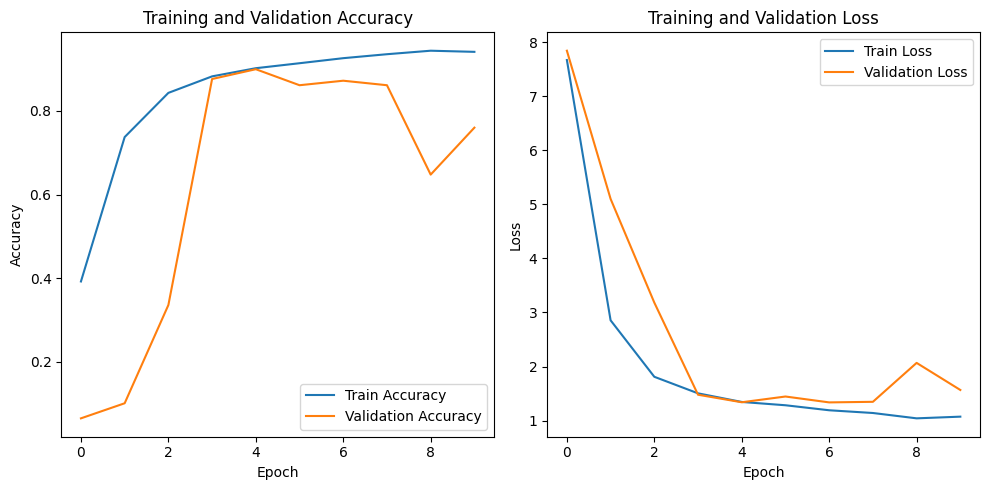

In [32]:
plot_history(his_4.history)

        *   Fifth Deep Neural Network


In [33]:
model_5=Sequential()

model_5=Sequential([
    Conv2D(16,(3,3),strides=1,activation='relu', input_shape=(32, 32, 3)),
    Conv2D(32,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(64,(3,3),strides=1,activation='relu'),
    Conv2D(128,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Flatten(),

    Dense(128,activation='relu',kernel_regularizer=l1_l2(l1=0.0001, l2=0.0001)),
    Dropout(0.5),
    Dense(28,activation='softmax'),
  ])
model_5.summary()

model_5.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,420 (1.95 MB)

 Trainable params: 511,100 (1.95 MB)

 Non-trainable params: 320 (1.25 KB)

In [34]:
his_5 = model_5.fit(train, train_labels, epochs=10, validation_split=0.2, batch_size=64)

Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.3787 - loss: 2.9589 - val_accuracy: 0.0324 - val_loss: 6.0441
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7107 - loss: 1.6676 - val_accuracy: 0.0402 - val_loss: 6.1239
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8387 - loss: 1.2209 - val_accuracy: 0.5097 - val_loss: 2.1685
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8812 - loss: 1.0081 - val_accuracy: 0.8564 - val_loss: 1.0441
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9118 - loss: 0.8472 - val_accuracy: 0.9163 - val_loss: 0.8168
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9333 - loss: 0.7304 - val_accuracy: 0.9014 - val_loss: 0.8355
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9415 - loss: 0.6626 - val_accuracy: 0.9241 - val_loss: 0.7049
Epoch 8/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9523 - loss: 0.5973 - val_accu

In [35]:
loss, acc = model_5.evaluate(test, test_labels)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8685 - loss: 0.8681


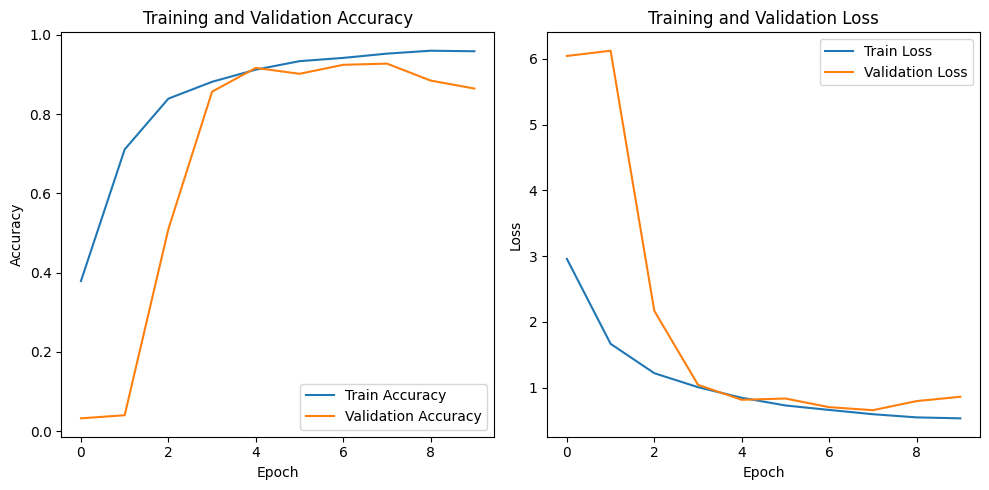

In [36]:
plot_history(his_5.history)

        *   Sixth Deep Neural Network


In [37]:
model_6=Sequential()

model_6=Sequential([
    Conv2D(16,(3,3),strides=1,activation='relu', input_shape=(32, 32, 3)),
    Conv2D(32,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(64,(3,3),strides=1,activation='relu'),
    Conv2D(128,(3,3),strides=1,activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Flatten(),

    Dense(128,activation='relu',kernel_regularizer=l1_l2(l1=0.0001, l2=0.0001)),
    Dropout(0.5),
    Dense(28,activation='softmax'),
  ])
model_6.summary()

model_6.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,420 (1.95 MB)

 Trainable params: 511,100 (1.95 MB)

 Non-trainable params: 320 (1.25 KB)

In [38]:
his_6 = model_6.fit(train, train_labels, epochs=10, validation_split=0.2, batch_size=32)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3958 - loss: 2.9196 - val_accuracy: 0.0636 - val_loss: 9.6037
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7318 - loss: 1.5928 - val_accuracy: 0.7325 - val_loss: 1.5441
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8449 - loss: 1.1348 - val_accuracy: 0.8181 - val_loss: 1.1654
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8903 - loss: 0.9126 - val_accuracy: 0.8318 - val_loss: 1.0331
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9092 - loss: 0.7881 - val_accuracy: 0.8973 - val_loss: 0.8330
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9276 - loss: 0.7034 - val_accuracy: 0.9334 - val_loss: 0.6877
Epoch 7/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9348 - loss: 0.6592 - val_accuracy: 0.7612 - val_loss: 1.2690
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9429 - loss: 0.6081 - val_accu

In [39]:
loss, acc = model_6.evaluate(test, test_labels)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9497 - loss: 0.5945


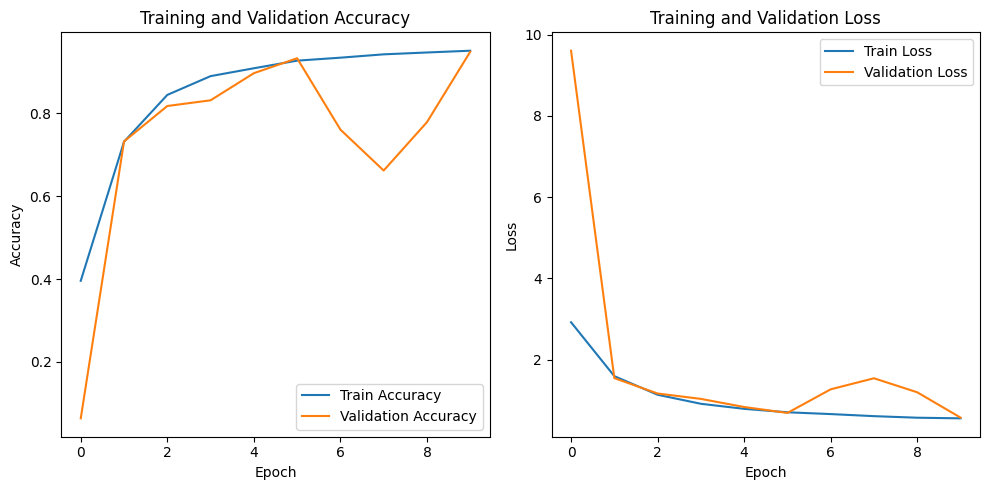

In [40]:
plot_history(his_6.history)

In [41]:
plot_model(model_6, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [42]:
model_6.save('Deep_Learning.keras')

In [43]:
from sklearn.metrics import classification_report
import numpy as np

predictions = model_6.predict(test)
predicted_classes = np.argmax(predictions, axis=1)

report = classification_report(test_labels, predicted_classes)

print(report)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       120
           1       0.99      1.00      1.00       120
           2       0.96      0.99      0.98       120
           3       0.98      0.90      0.94       120
           4       0.90      0.98      0.94       120
           5       0.94      0.97      0.96       120
           6       0.99      0.92      0.95       120
           7       0.86      0.95      0.90       120
           8       0.97      0.94      0.96       120
           9       0.97      0.97      0.97       120
          10       0.98      0.95      0.97       120
          11       0.97      0.89      0.93       120
          12       0.98      1.00      0.99       120
          13       0.98      0.98      0.98       120
          14       0.95      0.87      0.91       120
          15       0.98      0.91      0.94       120
          16       0.89      0.97      0

In [44]:
import cv2
import numpy as np
import tensorflow as tf
import os
from sklearn.preprocessing import LabelEncoder

# 1. Setup the Alphabetical Labels (This matches LabelEncoder's fit_transform logic)
ARABIC_LABELS = [
    'ain', 'alef', 'beh', 'dad', 'dal', 'feh', 'ghain', 'hah', 'heh', 'jeem', 
    'kaf', 'khah', 'lam', 'meem', 'noon', 'qaf', 'reh', 'sad', 'seen', 'sheen', 
    'tah', 'teh', 'thal', 'theh', 'waw', 'yeh', 'zah', 'zain'
]

MODEL_PATH = 'Deep_Learning.keras'
IMAGE_PATH = 'test_letter.png'

def preprocess_handwriting(img_path):
    # Read the image
    img = cv2.imread(img_path)
    if img is None:
        return None, None
    
    # A. Grayscale and Blur to remove camera noise
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    
    # B. Thresholding: Convert to White Ink on Black Background
    # (Matches the style of most Arabic Handwriting datasets)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # C. Find ALL ink components (Main body + any floating dots)
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not cnts:
        return None, None

    # D. Create a bounding box that wraps around EVERY detected piece
    x_min, y_min = np.inf, np.inf
    x_max, y_max = -np.inf, -np.inf
    for c in cnts:
        if cv2.contourArea(c) > 20: # Filter out tiny dust particles
            x, y, w, h = cv2.boundingRect(c)
            x_min, y_min = min(x_min, x), min(y_min, y)
            x_max, y_max = max(x_max, x + w), max(y_max, y + h)

    # E. Crop the region of interest
    roi = thresh[int(y_min):int(y_max), int(x_min):int(x_max)]
    
    # F. Square Padding: Prevent the letter from being squashed during resize
    h, w = roi.shape
    side = int(max(h, w) * 1.4) # Add 40% padding around the letter
    canvas = np.zeros((side, side), dtype="uint8")
    
    # Center the ROI in the square canvas
    off_x, off_y = (side - w) // 2, (side - h) // 2
    canvas[off_y:off_y+h, off_x:off_x+w] = roi
    
    # G. Final Formatting: 32x32, 3-Channel BGR, Normalized to [0,1]
    resized = cv2.resize(canvas, (32, 32), interpolation=cv2.INTER_AREA)
    final_bgr = cv2.cvtColor(resized, cv2.COLOR_GRAY2BGR)
    normalized = final_bgr.astype('float32') / 255.0 # Exactly matches your train/255.0 snippet
    
    return normalized, img

def predict_letter():
    # Load your model
    if not os.path.exists(MODEL_PATH):
        print(f"Model file '{MODEL_PATH}' not found!")
        return

    model = tf.keras.models.load_model(MODEL_PATH)
    
    # Get the processed image
    processed_img, original_view = preprocess_handwriting(IMAGE_PATH)
    
    if processed_img is not None:
        # Add batch dimension (1, 32, 32, 3)
        input_data = np.expand_dims(processed_img, axis=0)
        
        # Predict
        predictions = model.predict(input_data, verbose=0)
        predicted_idx = np.argmax(predictions)
        label = ARABIC_LABELS[predicted_idx]
        confidence = np.max(predictions)
        
        # Output
        print("-" * 30)
        print(f"PREDICTED CHARACTER: {label.upper()}")
        print(f"CONFIDENCE: {confidence:.2%}")
        print("-" * 30)
        
        # Show what happened
        cv2.imshow("Original Input", original_view)
        # Show AI vision zoomed in for clarity
        debug_view = cv2.resize(processed_img, (300, 300), interpolation=cv2.INTER_NEAREST)
        cv2.imshow("AI Vision (32x32 Normalized)", debug_view)
        
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    else:
        print("Error: No character detected in the image.")

if __name__ == "__main__":
    predict_letter()


------------------------------
PREDICTED CHARACTER: TEH
CONFIDENCE: 100.00%
------------------------------
